# CONDOR — Visualización de Extensive Air Showers (EAS)

Análisis visual del dataset de simulaciones CORSIKA para el observatorio CONDOR (5 300 m s.n.m., Atacama).  
Partículas primarias: **protón** (hadrón) y **fotón** (γ).  
Energías: 300, 500 y 800 GeV — Ángulo cenital: 0°–40°.

In [1]:
import os
import sys
import pickle
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# ─── Paths ────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

BASE_DIR = Path.cwd()  # run from the code/ directory (Jupyter default)
CACHE_FILE    = BASE_DIR / "processed_all_data.pkl"
ARTIFACTS_DIR = BASE_DIR / "pipeline_artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
VIZ_DIR = ARTIFACTS_DIR / "eas_visualizations"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

# ─── Paleta CONDOR compartida (condorlib.style) ────────────────
# Paleta elegida por Luis para los footprints (11-sep-2026, tras comparar
# variantes en pipeline_artifacts/cmap_compare.png): rojo muy claro -> negro,
# reusando los tonos de CMAP_SEQ (misma familia que la Fig. 2.4) con el
# extremo oscuro en negro (PROTON) en vez de rojo GAMMA, para que el t_bin
# bajo (núcleo, la mayoría de los detectores) se vea claramente más claro
# que el borde/llegada tardía.
sys.path.insert(0, str(BASE_DIR.parent))
from condorlib import style as condor_style
CMAP_FOOTPRINT = LinearSegmentedColormap.from_list(
    "condor_footprint", ["#F2D5D9", "#D08A94", condor_style.GAMMA, condor_style.PROTON]
)

# ─── Filtros del dataset ──────────────────────────────────────
ENERGY_FILTER       = ("3E2", "5E2", "8E2")
ANGLE_MAX           = 40.0
MIN_TOTAL_PARTICLES = 30
LABEL_MAP           = {0: "Proton", 1: "Photon"}

# ─── Paleta CONDOR ────────────────────────────────────────────
CONDOR_RED   = "#6E1423"
CONDOR_BLACK = "#1A1A1A"
CONDOR_GRAY  = "#CCCCCC"
CONDOR_GREEN = "#4A7C59"

PARTICLE_COLORS = {"Photon": CONDOR_RED, "Proton": CONDOR_BLACK}

# ─── Constantes globales ──────────────────────────────────────
ENERGIES_SORTED = ["3E2", "5E2", "8E2"]
ENERGY_LABELS   = {"3E2": "300 GeV", "5E2": "500 GeV", "8E2": "800 GeV"}
PARTICLES_LIST  = ["Proton", "Photon"]
SHOWCASE_ANGLE  = 0.0
ANGLE_TOL       = 1.0

# ─── Estilo global ────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
})
sns.set_context("talk")

In [2]:
# ----------------------------- #
# Carga del dataset procesado   #
# ----------------------------- #
def load_dataset_from_cache(cache_path: Path) -> pd.DataFrame:
    if not cache_path.exists():
        raise FileNotFoundError(
            f"No se encontró {cache_path}. Regenera el pickle antes de continuar."
        )
    with cache_path.open("rb") as fh:
        data = pickle.load(fh)
    if isinstance(data, pd.DataFrame):
        df = data.copy()
    elif isinstance(data, dict):
        df = pd.DataFrame(data)
    else:
        raise ValueError("Formato de caché no soportado.")
    required_cols = {"shower_data", "angle", "label", "energy", "total_particles", "max_time"}
    if not required_cols.issubset(df.columns):
        raise ValueError("El pickle no contiene todas las columnas necesarias.")
    return df.reset_index(drop=True)

df_raw = load_dataset_from_cache(CACHE_FILE)

df_filtered = df_raw[
    (df_raw["energy"].isin(ENERGY_FILTER)) &
    (df_raw["angle"] <= ANGLE_MAX) &
    (df_raw["total_particles"] >= MIN_TOTAL_PARTICLES)
].reset_index(drop=True)

print(f"Eventos disponibles (raw): {len(df_raw)}")
print(f"Eventos tras filtrado: {len(df_filtered)}")

df_filtered["particle"] = df_filtered["label"].map(LABEL_MAP)
df_filtered["energy_GeV"] = df_filtered["energy"].str.replace("E", "e").astype(float)

Eventos disponibles (raw): 271357
Eventos tras filtrado: 96988


In [3]:
# ----------------------------- #
# Catálogo de detectores        #
# ----------------------------- #
def build_detector_catalog(df: pd.DataFrame) -> pd.DataFrame:
    positions = []
    for seq in df["shower_data"]:
        arr = np.asarray(seq, dtype=np.float32)
        if arr.size == 0:
            continue
        positions.append(arr[:, [0, 5, 6]])
    if not positions:
        return pd.DataFrame(columns=["detector_id", "x_center", "y_center"])
    catalog = (
        pd.DataFrame(np.vstack(positions), columns=["detector_id", "x_center", "y_center"])
        .drop_duplicates(subset=["detector_id"])
        .sort_values("detector_id")
        .reset_index(drop=True)
    )
    catalog["detector_id"] = catalog["detector_id"].astype(int)
    return catalog

detector_catalog = build_detector_catalog(df_filtered)
detector_catalog.to_csv(ARTIFACTS_DIR / "detector_catalog.csv", index=False)

---
## 1. Distribuciones del dataset

Conteos de eventos por energía, ángulo cenital, y estadísticas de las secuencias temporales.

2685041399.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([ENERGY_LABELS[e] for e in order])


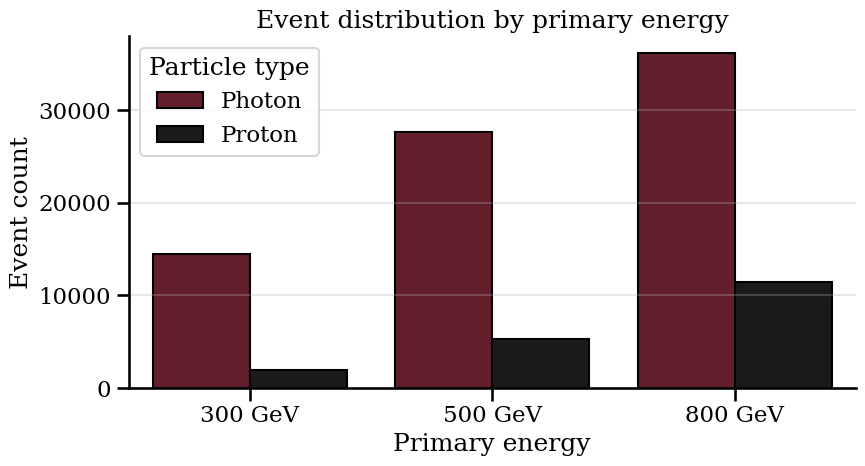

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
order = sorted(df_filtered["energy"].unique(),
               key=lambda x: float(x.replace("E", "e")))
sns.countplot(
    data=df_filtered, x="energy", hue="particle",
    order=order, palette=PARTICLE_COLORS,
    edgecolor="black", ax=ax,
)
ax.set_xticklabels([ENERGY_LABELS[e] for e in order])
ax.set_title("Event distribution by primary energy")
ax.set_xlabel("Primary energy")
ax.set_ylabel("Event count")
ax.legend(title="Particle type")
plt.tight_layout()
plt.savefig(VIZ_DIR / "dist_energy.png", dpi=150, bbox_inches="tight")
plt.show()

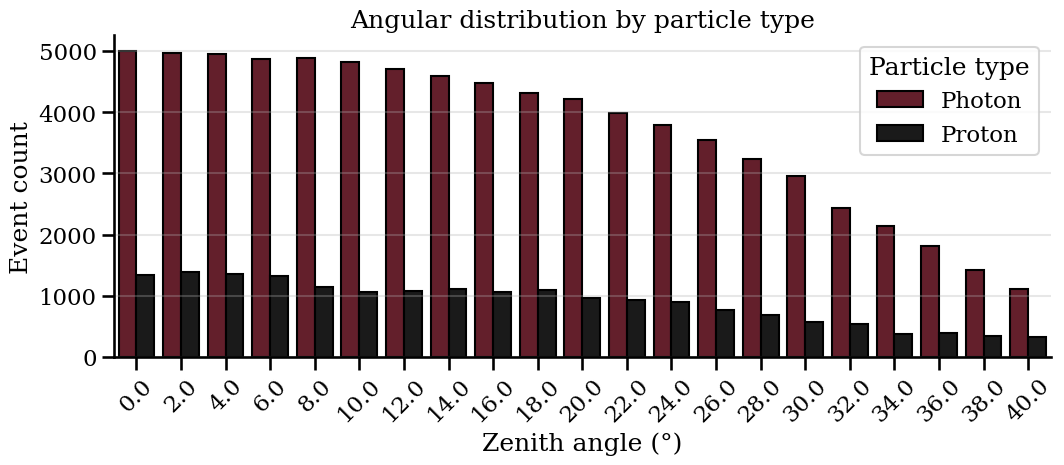

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.countplot(
    data=df_filtered, x="angle", hue="particle",
    palette=PARTICLE_COLORS, edgecolor="black", ax=ax,
)
ax.set_title("Angular distribution by particle type")
ax.set_xlabel("Zenith angle (°)")
ax.set_ylabel("Event count")
ax.legend(title="Particle type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(VIZ_DIR / "dist_angle.png", dpi=150, bbox_inches="tight")
plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
386419768.py:22: SyntaxWarning: invalid escape sequence '\m'
  axes[2].set_title("Maximum $t_\mathrm{bin}$ per event")
386419768.py:23: SyntaxWarning: invalid escape sequence '\m'
  axes[2].set_xlabel("Maximum $t_\mathrm{bin}$")


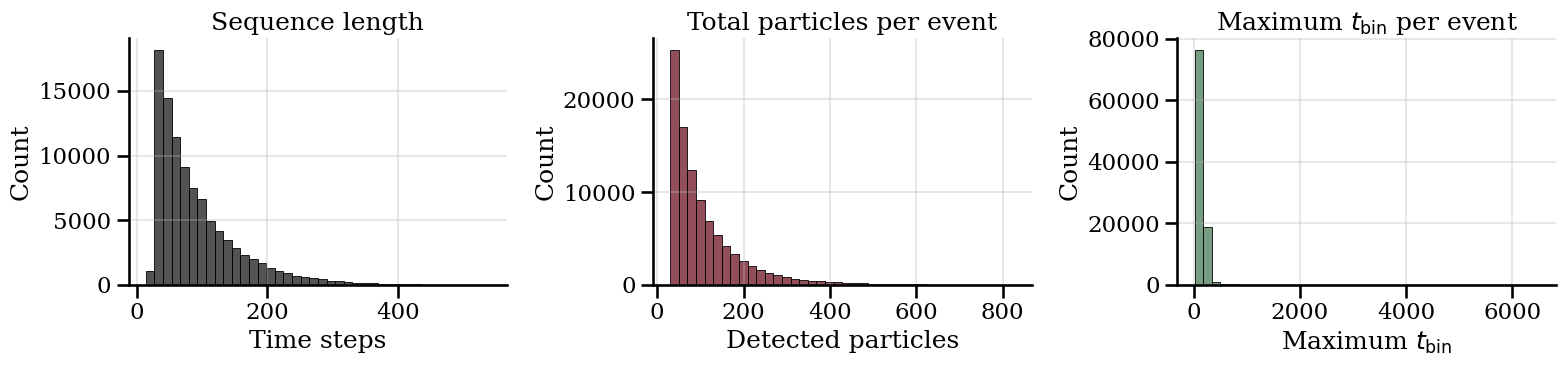

Resumen de longitud de secuencias:
  Media: 91.5
  Percentiles (50/90/95/99): [ 71. 179. 223. 319.]


In [6]:
def sequence_length(seq):
    arr = np.asarray(seq)
    return arr.shape[0] if arr.ndim == 2 else 0

seq_lengths  = df_filtered["shower_data"].apply(sequence_length)
tot_particles = df_filtered["total_particles"]
max_times     = df_filtered["max_time"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(seq_lengths, bins=40, color=CONDOR_BLACK, ax=axes[0])
axes[0].set_title("Sequence length")
axes[0].set_xlabel("Time steps")
axes[0].set_ylabel("Count")

sns.histplot(tot_particles, bins=40, color=CONDOR_RED, ax=axes[1])
axes[1].set_title("Total particles per event")
axes[1].set_xlabel("Detected particles")
axes[1].set_ylabel("Count")

sns.histplot(max_times, bins=40, color=CONDOR_GREEN, ax=axes[2])
axes[2].set_title("Maximum $t_\mathrm{bin}$ per event")
axes[2].set_xlabel("Maximum $t_\mathrm{bin}$")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig(VIZ_DIR / "dist_sequences.png", dpi=150, bbox_inches="tight")
plt.show()

print("Resumen de longitud de secuencias:")
print(f"  Media: {seq_lengths.mean():.1f}")
print(f"  Percentiles (50/90/95/99): {np.percentile(seq_lengths, [50, 90, 95, 99])}")

---
## 2. Ejemplo detallado de un evento

Evento con mayor número de partículas en el dataset filtrado. Muestra la estructura cruda de `shower_data` (9 columnas por hit).

In [7]:
# ----------------------------- #
# Ejemplo de evento detallado   #
# ----------------------------- #
example_idx = df_filtered["total_particles"].idxmax()
example_row = df_filtered.loc[example_idx]
example_seq = np.asarray(example_row["shower_data"], dtype=np.float32)

example_df = pd.DataFrame(example_seq, columns=[
    "detector_id", "t_bin", "particle_count", "mean_x", "mean_y",
    "x_center", "y_center", "total_energy", "percentage_in_condor"
])

print(
    f"Ejemplo seleccionado (idx {example_idx})\n"
    f"  Partícula: {LABEL_MAP[example_row['label']]}\n"
    f"  Energía: {example_row['energy']} (≈ {example_row['energy_GeV']:.0f} GeV)\n"
    f"  Ángulo: {example_row['angle']}°\n"
    f"  Total partículas: {example_row['total_particles']}"
)
display(example_df.head(12))

Ejemplo seleccionado (idx 69175)
  Partícula: Photon
  Energía: 8E2 (≈ 800 GeV)
  Ángulo: 2.0°
  Total partículas: 827


,detector_id,t_bin,particle_count,mean_x,mean_y,x_center,y_center,total_energy,percentage_in_condor
0,15.0,0.0,2.0,-29.597479,5.893435,-29.75,4.5,0.411122,82.0
1,23.0,1.0,1.0,-18.831854,-9.773375,-21.25,-13.5,0.340962,82.0
2,16.0,1.0,1.0,-28.885906,13.413513,-29.75,13.5,0.077727,82.0
3,17.0,1.0,1.0,-27.946129,24.600803,-29.75,22.5,0.015701,82.0
4,43.0,1.0,1.0,-7.401192,-16.644300,-4.25,-13.5,1.269980,82.0
5,6.0,1.0,1.0,-40.692093,17.363276,-38.25,13.5,0.059771,82.0
6,25.0,1.0,1.0,-19.096794,5.694922,-21.25,4.5,0.219786,82.0
7,45.0,1.0,8.0,-6.875089,3.095016,-4.25,4.5,4.935128,82.0
8,44.0,1.0,2.0,-6.589417,-5.705317,-4.25,-4.5,0.736688,82.0
9,26.0,1.0,1.0,-22.245588,12.491651,-21.25,13.5,0.150824,82.0


---
## 3. Estadísticas por tipo, energía y ángulo

Media de partículas detectadas, t_bin máximo y energía total como función del ángulo cenital, separadas por tipo de partícula y energía.

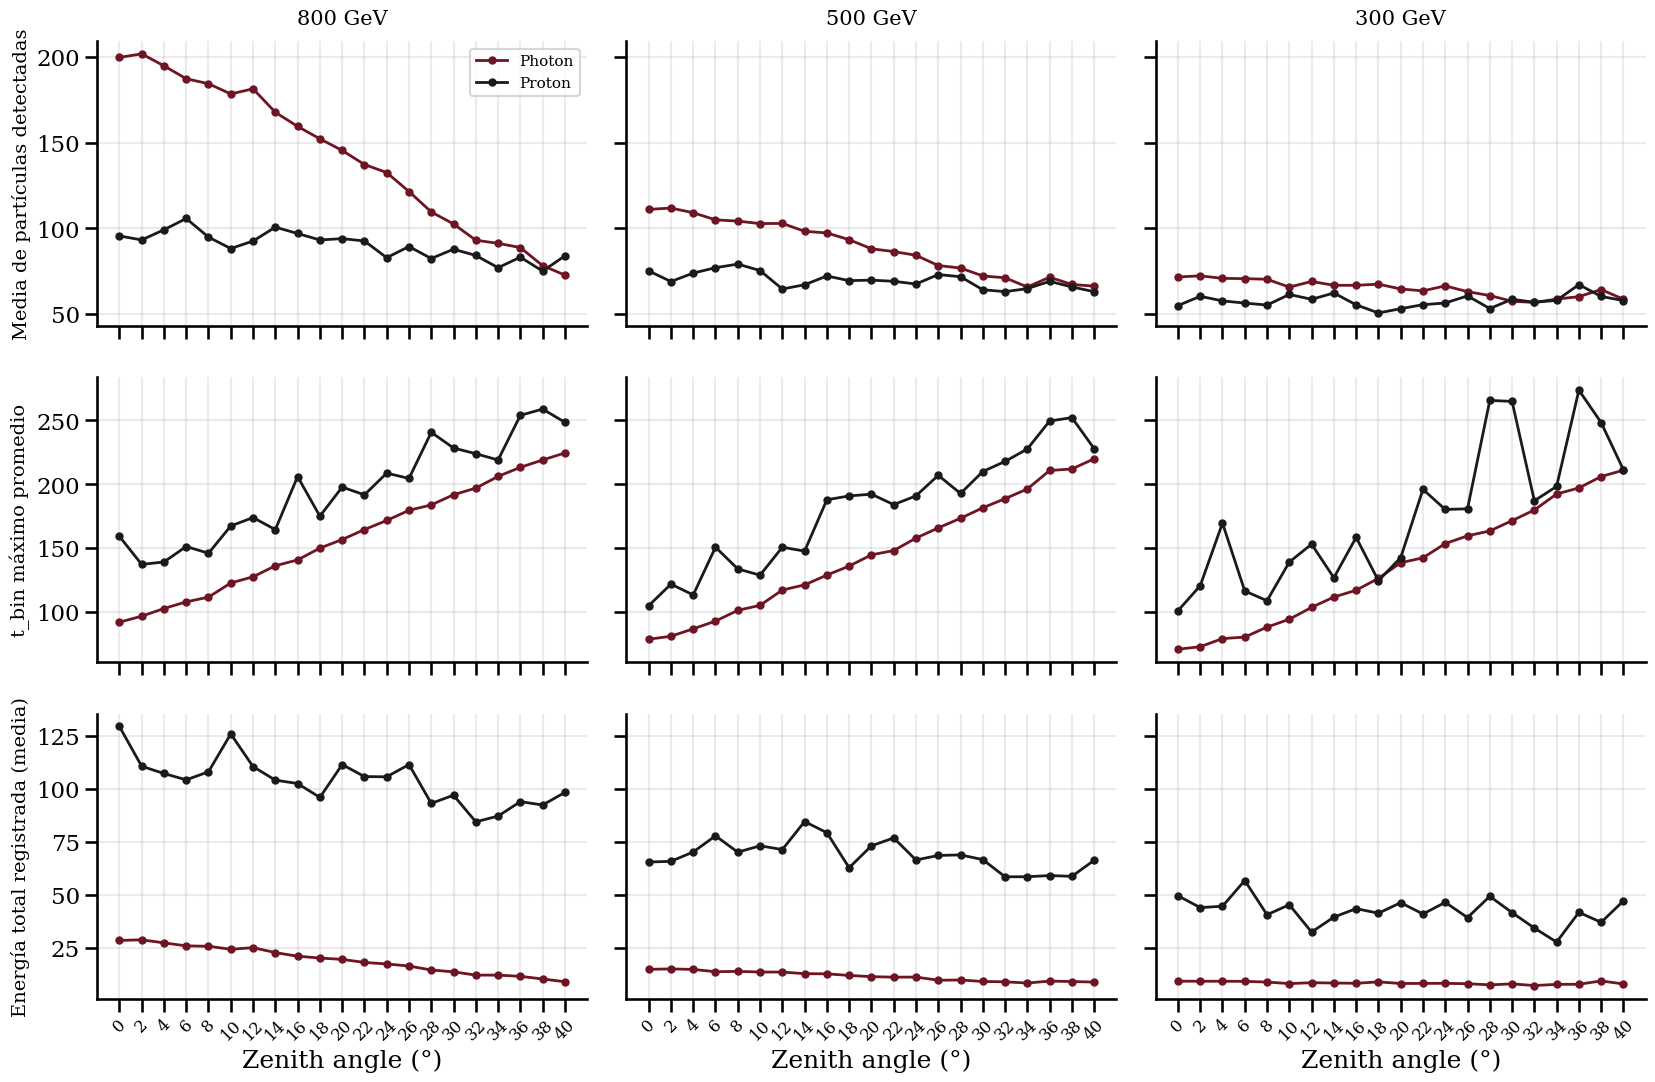

In [8]:
# ----------------------------- #
# Estadística por agrupaciones  #
# ----------------------------- #
def sequence_total_energy(seq: np.ndarray) -> float:
    arr = np.asarray(seq, dtype=np.float32)
    return float(arr[:, 7].sum()) if arr.ndim == 2 and arr.size else 0.0

if "total_energy_seq" not in df_filtered.columns:
    df_filtered["total_energy_seq"] = df_filtered["shower_data"].apply(sequence_total_energy)

energy_order = sorted(
    df_filtered["energy"].unique(),
    key=lambda x: float(x.replace("E", "e")),
    reverse=True,
)
energy_labels = {e: f"{float(e.replace('E', 'e')):,.0f} GeV" for e in energy_order}
angles = np.sort(df_filtered["angle"].unique())

metric_rows = [
    ("total_particles", "Media de partículas detectadas"),
    ("max_time", "t_bin máximo promedio"),
    ("total_energy_seq", "Energía total registrada (media)"),
]

nrows = len(metric_rows)
ncols = len(energy_order)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5.8 * ncols, 3.8 * nrows),
    sharex="col",
    sharey="row",
    constrained_layout=False,
)
plt.subplots_adjust(hspace=0.18, wspace=0.08, left=0.07, right=0.96, top=0.92, bottom=0.08)

if nrows == 1:
    axes = axes.reshape(1, -1)
if ncols == 1:
    axes = axes.reshape(-1, 1)

for col, energy in enumerate(energy_order):
    subset_energy = df_filtered[df_filtered["energy"] == energy]
    axes[0, col].set_title(energy_labels[energy], fontsize=15, pad=12)

    for row, (metric, ylabel) in enumerate(metric_rows):
        ax = axes[row, col]
        for particle, color in PARTICLE_COLORS.items():
            series = (
                subset_energy[subset_energy["particle"] == particle]
                .groupby("angle")[metric]
                .mean()
                .reindex(angles, fill_value=np.nan)
            )
            ax.plot(
                angles,
                series.values,
                marker="o",
                linewidth=2,
                markersize=5,
                label=particle,
                color=color,
            )

        if col == 0:
            ax.set_ylabel(ylabel, fontsize=14)
        if row == nrows - 1:
            ax.set_xlabel("Zenith angle (°)")
            ax.set_xticks(angles)
            ax.set_xticklabels([f"{a:.0f}" for a in angles], rotation=45, fontsize=12)
        else:
            ax.tick_params(axis="x", labelbottom=False)

        ax.grid(alpha=0.25)
        if col == 0 and row == 0:
            ax.legend(loc="upper right", fontsize=11)

plt.show()

---
## 4. Showcase de eventos individuales

Un evento representativo por categoría (tipo × energía) a θ ≈ 0°, seleccionado por proximidad a la mediana de `total_particles`.  
**Tamaño** ∝ partículas detectadas; **color** = $t_{bin}$ promedio.

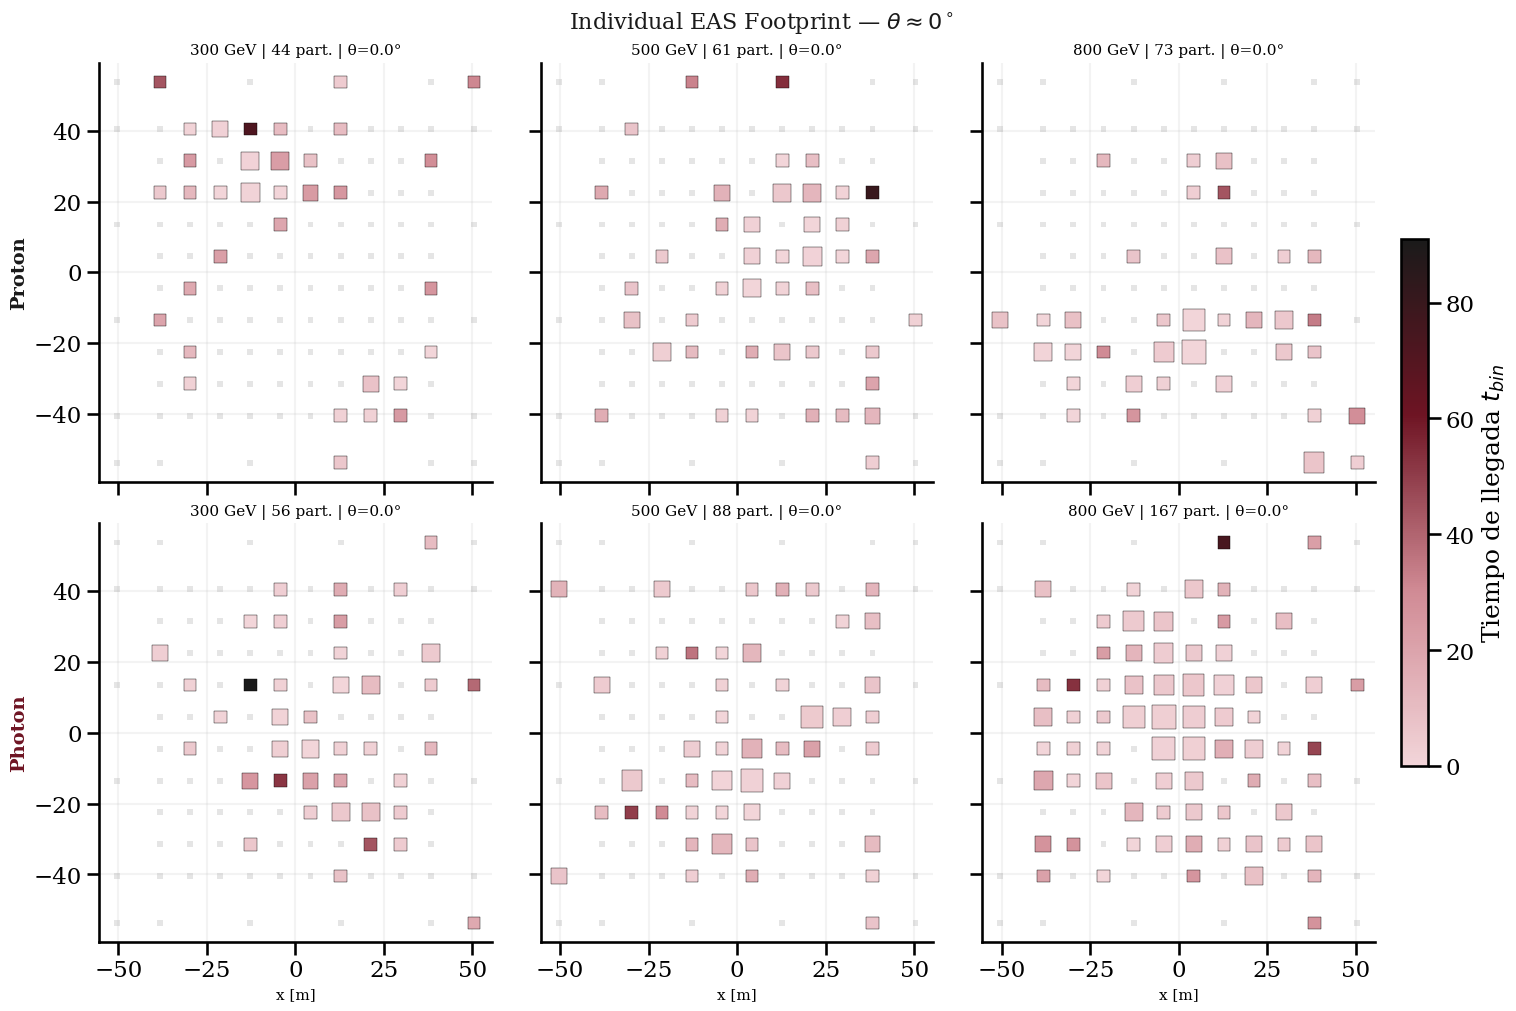

In [9]:
def get_representative_event(df, particle, energy, angle_target, tol=ANGLE_TOL):
    mask = (
        (df["particle"] == particle)
        & (df["energy"] == energy)
        & (df["angle"].between(angle_target - tol, angle_target + tol))
    )
    sub = df[mask]
    if sub.empty:
        return None
    median_n = sub["total_particles"].median()
    return sub.loc[(sub["total_particles"] - median_n).abs().idxmin()]


def shower_to_agg(row):
    arr = np.asarray(row["shower_data"], dtype=np.float32)
    if arr.size == 0:
        return None
    df_s = pd.DataFrame(
        arr[:, [0, 1, 2, 5, 6]],
        columns=["detector_id", "t_bin", "particle_count", "x_center", "y_center"],
    )
    df_s["detector_id"] = df_s["detector_id"].astype(int)
    return (
        df_s.groupby(["detector_id", "x_center", "y_center"])
        .agg(total_particles=("particle_count", "sum"), mean_tbin=("t_bin", "mean"))
        .reset_index()
    )


_vmin_t, _vmax_t = np.inf, -np.inf
for _p in PARTICLES_LIST:
    for _e in ENERGIES_SORTED:
        _ev = get_representative_event(df_filtered, _p, _e, SHOWCASE_ANGLE)
        if _ev is not None:
            _arr = np.asarray(_ev["shower_data"], dtype=np.float32)
            if _arr.size:
                _vmin_t = min(_vmin_t, float(_arr[:, 1].min()))
                _vmax_t = max(_vmax_t, float(_arr[:, 1].max()))

_norm_t = plt.Normalize(vmin=_vmin_t, vmax=_vmax_t)
_cmap_t = CMAP_FOOTPRINT

fig, axes = plt.subplots(
    len(PARTICLES_LIST), len(ENERGIES_SORTED),
    figsize=(5 * len(ENERGIES_SORTED), 5 * len(PARTICLES_LIST)),
    sharex=True, sharey=True, constrained_layout=True,
)
fig.suptitle(
    rf"Individual EAS Footprint — $\theta \approx {SHOWCASE_ANGLE:.0f}^\circ$",
    fontsize=16, color=CONDOR_BLACK,
)

for _row, _part in enumerate(PARTICLES_LIST):
    for _col, _en in enumerate(ENERGIES_SORTED):
        _ax = axes[_row, _col]
        _ev = get_representative_event(df_filtered, _part, _en, SHOWCASE_ANGLE)

        _ax.scatter(
            detector_catalog["x_center"], detector_catalog["y_center"],
            c=CONDOR_GRAY, s=18, marker="s", edgecolor="none", alpha=0.5, zorder=1,
        )

        if _ev is not None:
            _agg = shower_to_agg(_ev)
            if _agg is not None:
                _s = np.clip(np.log1p(_agg["total_particles"]) * 120, 20, 900)
                _ax.scatter(
                    _agg["x_center"], _agg["y_center"],
                    s=_s, c=_agg["mean_tbin"],
                    cmap=_cmap_t, norm=_norm_t,
                    marker="s", edgecolor="k", linewidth=0.3, zorder=2,
                )
                _ax.set_title(
                    f"{ENERGY_LABELS[_en]} | {int(_ev['total_particles'])} part. | "
                    f"θ={_ev['angle']}°",
                    fontsize=11,
                )

        _ax.set_aspect("equal")
        _ax.grid(alpha=0.15)
        if _col == 0:
            _ax.set_ylabel(
                _part, fontsize=14, color=PARTICLE_COLORS[_part], fontweight="bold",
            )
        if _row == len(PARTICLES_LIST) - 1:
            _ax.set_xlabel("x [m]", fontsize=11)

fig.colorbar(
    plt.cm.ScalarMappable(norm=_norm_t, cmap=_cmap_t),
    ax=axes, label=r"Tiempo de llegada $t_{bin}$",
    shrink=0.6, pad=0.02,
)
plt.savefig(VIZ_DIR / "shower_individual_showcase.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Footprint promedio por categoría

**5a.** Grilla tipo × energía a θ ≈ 0°.  **5b.** Evolución angular a E = 500 GeV.  
Tamaño ∝ partículas/evento; color = $\bar{t}_{bin}$.  
⚠ Las celdas siguientes iteran sobre ~14 000 eventos — ~30 s en total.

Calculando footprints promedio (grilla 2x3)...


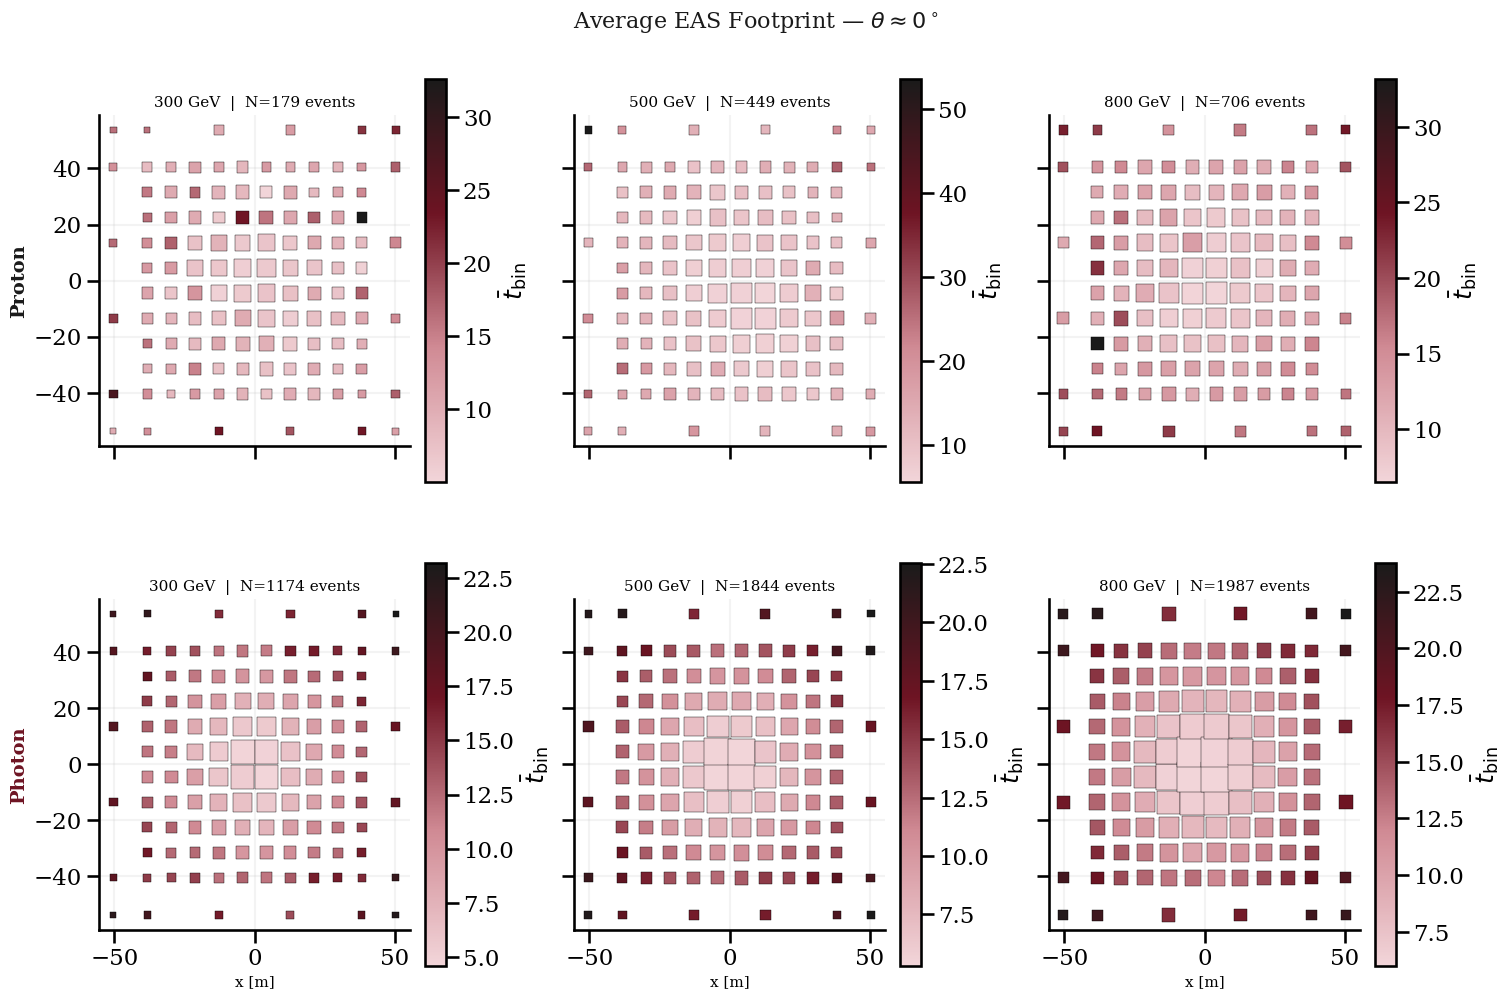

In [10]:
# ============================================================ #
# Sección 2a — Footprint promedio: grilla tipo × energía       #
# ============================================================ #

def compute_avg_footprint(df_sub):
    records, n_valid = [], 0
    for _, row in df_sub.iterrows():
        arr = np.asarray(row["shower_data"], dtype=np.float32)
        if arr.size == 0:
            continue
        records.append(arr[:, [0, 1, 2, 5, 6]])
        n_valid += 1
    if n_valid == 0:
        return None, 0
    combined = np.vstack(records)
    df_c = pd.DataFrame(
        combined,
        columns=["detector_id", "t_bin", "particle_count", "x_center", "y_center"],
    )
    df_c["detector_id"] = df_c["detector_id"].astype(int)
    agg = (
        df_c.groupby(["detector_id", "x_center", "y_center"])
        .agg(sum_particles=("particle_count", "sum"), avg_tbin=("t_bin", "mean"))
        .reset_index()
    )
    agg["avg_particles"] = agg["sum_particles"] / n_valid
    return agg, n_valid


print("Calculando footprints promedio (grilla 2x3)...")
fig2a, axes2a = plt.subplots(
    len(PARTICLES_LIST), len(ENERGIES_SORTED),
    figsize=(5 * len(ENERGIES_SORTED), 5 * len(PARTICLES_LIST)),
    sharex=True, sharey=True,
    constrained_layout=True,
)
fig2a.suptitle(
    rf"Average EAS Footprint — $\theta \approx {SHOWCASE_ANGLE:.0f}^\circ$",
    fontsize=16, color=CONDOR_BLACK,
)

for _row, _part in enumerate(PARTICLES_LIST):
    for _col, _en in enumerate(ENERGIES_SORTED):
        _ax = axes2a[_row, _col]
        _mask = (
            (df_filtered["particle"] == _part)
            & (df_filtered["energy"] == _en)
            & (df_filtered["angle"].between(SHOWCASE_ANGLE - ANGLE_TOL, SHOWCASE_ANGLE + ANGLE_TOL))
        )
        _avg_df, _n = compute_avg_footprint(df_filtered[_mask])

        _ax.scatter(detector_catalog["x_center"], detector_catalog["y_center"],
                    c=CONDOR_GRAY, s=18, marker="s", edgecolor="none", alpha=0.5, zorder=1)

        if _avg_df is not None:
            _s  = np.clip(np.log1p(_avg_df["avg_particles"]) * 200, 20, 900)
            _sc = _ax.scatter(
                _avg_df["x_center"], _avg_df["y_center"],
                s=_s, c=_avg_df["avg_tbin"],
                cmap=CMAP_FOOTPRINT, marker="s",
                edgecolor="k", linewidth=0.3, zorder=2,
            )
            fig2a.colorbar(_sc, ax=_ax, label=r"$\bar{t}_\mathrm{bin}$", shrink=0.85)
            _ax.set_title(f"{ENERGY_LABELS[_en]}  |  N={_n} events", fontsize=11)

        _ax.set_aspect("equal")
        _ax.grid(alpha=0.15)
        if _col == 0:
            _ax.set_ylabel(_part, fontsize=14,
                           color=PARTICLE_COLORS[_part], fontweight="bold")
        if _row == len(PARTICLES_LIST) - 1:
            _ax.set_xlabel("x [m]", fontsize=11)

plt.savefig(VIZ_DIR / "shower_avg_footprint_2x3.png", dpi=150, bbox_inches="tight")
plt.show()


Calculando evolucion angular (E=500 GeV)...


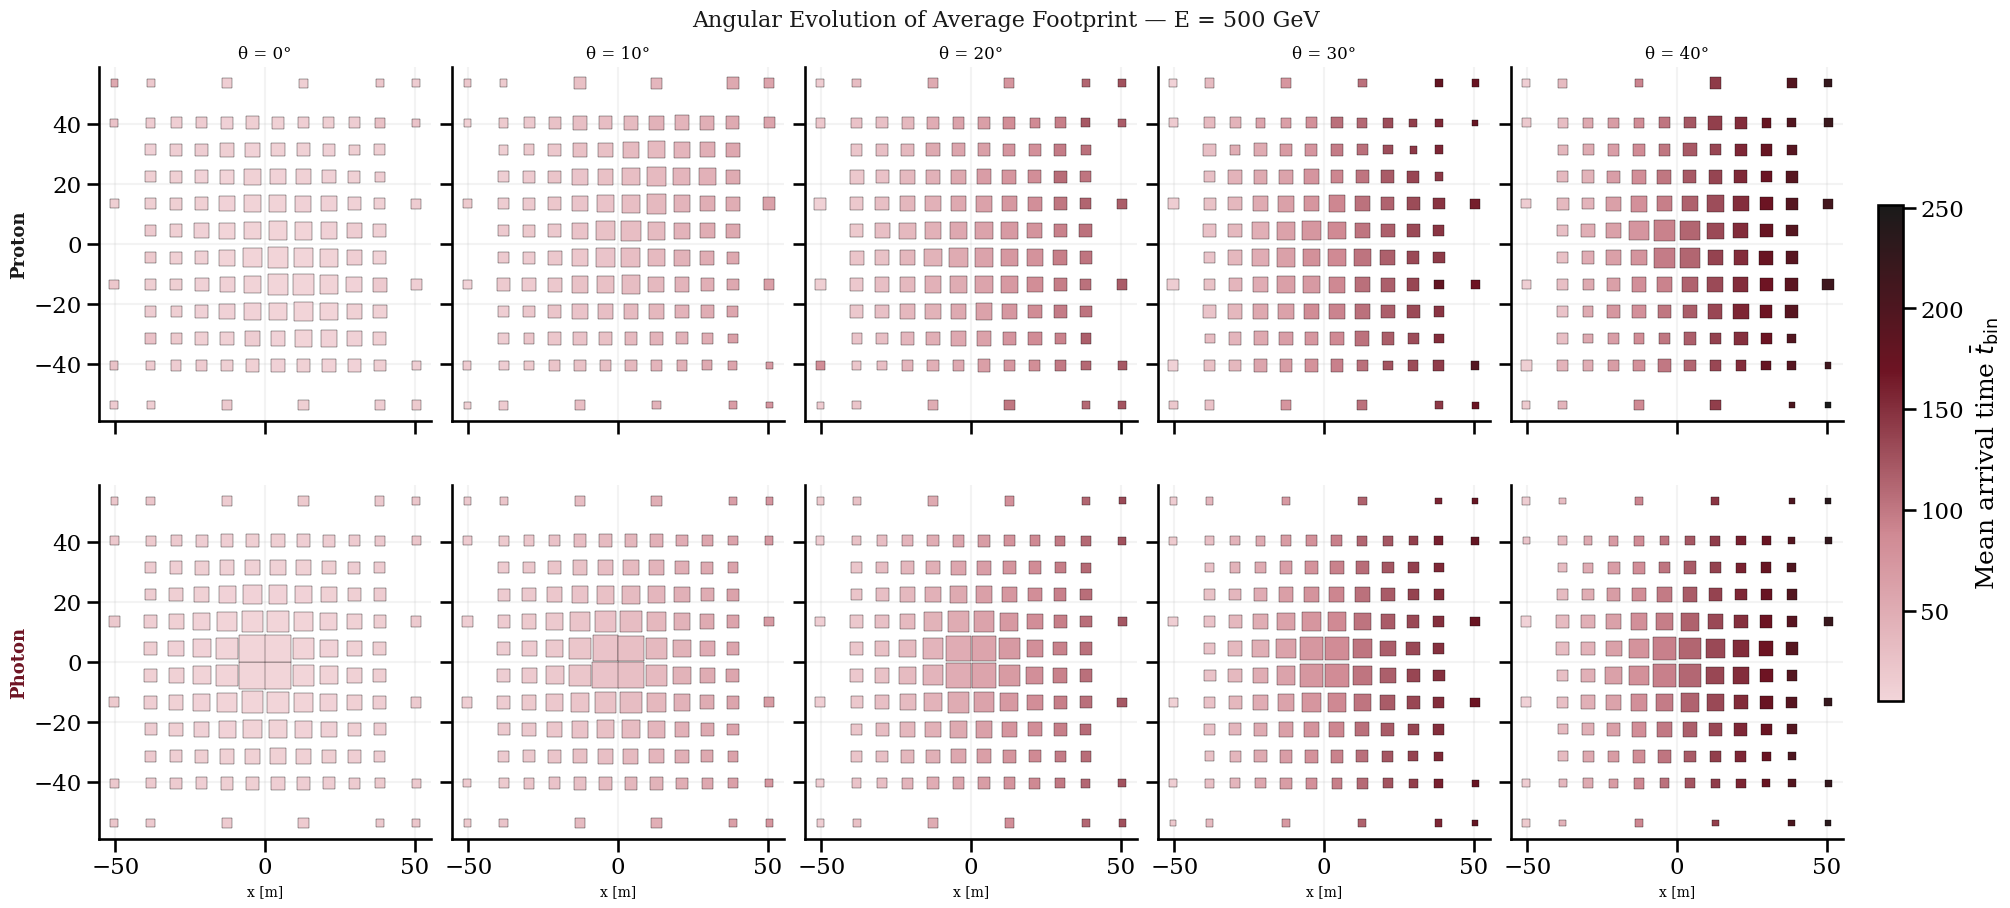

In [11]:
# ============================================================ #
# Sección 2b — Evolución angular a E = 500 GeV                 #
# ============================================================ #
ANG_EVO_LEVELS = [0.0, 10.0, 20.0, 30.0, 40.0]
ENERGY_ANG_EVO = "5E2"

print(f"Calculando evolucion angular (E={ENERGY_LABELS[ENERGY_ANG_EVO]})...")

# Pre-pase: rango global de tiempo y máximo de partículas (para escala de tamaño)
_t_min, _t_max = np.inf, -np.inf
_p_max = 0.0
_panels_data = {}
for _p in PARTICLES_LIST:
    for _ang in ANG_EVO_LEVELS:
        _mask = (
            (df_filtered["particle"] == _p)
            & (df_filtered["energy"] == ENERGY_ANG_EVO)
            & (df_filtered["angle"].between(_ang - ANGLE_TOL, _ang + ANGLE_TOL))
        )
        _res, _n = compute_avg_footprint(df_filtered[_mask])
        _panels_data[(_p, _ang)] = (_res, _n)
        if _res is not None and not _res.empty:
            _t_min = min(_t_min, float(_res["avg_tbin"].min()))
            _t_max = max(_t_max, float(_res["avg_tbin"].max()))
            _p_max = max(_p_max, float(_res["avg_particles"].max()))

_norm_t = plt.Normalize(_t_min, _t_max)
_cmap_t = CMAP_FOOTPRINT

fig2b, axes2b = plt.subplots(
    len(PARTICLES_LIST), len(ANG_EVO_LEVELS),
    figsize=(4 * len(ANG_EVO_LEVELS), 4.5 * len(PARTICLES_LIST)),
    sharex=True, sharey=True,
    constrained_layout=True,
)
fig2b.suptitle(
    f"Angular Evolution of Average Footprint — E = {ENERGY_LABELS[ENERGY_ANG_EVO]}",
    fontsize=16, color=CONDOR_BLACK,
)

for _row, _part in enumerate(PARTICLES_LIST):
    for _col, _ang in enumerate(ANG_EVO_LEVELS):
        _ax = axes2b[_row, _col]
        _avg_df, _n = _panels_data[(_part, _ang)]

        _ax.scatter(detector_catalog["x_center"], detector_catalog["y_center"],
                    c=CONDOR_GRAY, s=15, marker="s", edgecolor="none", alpha=0.4, zorder=1)
        if _avg_df is not None and not _avg_df.empty:
            # tamaño ∝ partículas (log-escalado, como en la celda 15)
            _s = np.clip(np.log1p(_avg_df["avg_particles"]) * 200, 15, 500)
            _ax.scatter(
                _avg_df["x_center"], _avg_df["y_center"],
                s=_s, c=_avg_df["avg_tbin"],
                cmap=_cmap_t, norm=_norm_t,
                marker="s", edgecolor="k", linewidth=0.25, zorder=2,
            )

        _ax.set_aspect("equal")
        _ax.grid(alpha=0.15)
        if _row == 0:
            _ax.set_title(f"θ = {_ang:.0f}°", fontsize=12)
        if _col == 0:
            _ax.set_ylabel(_part, fontsize=13,
                           color=PARTICLE_COLORS[_part], fontweight="bold")
        if _row == len(PARTICLES_LIST) - 1:
            _ax.set_xlabel("x [m]", fontsize=10)

fig2b.colorbar(
    plt.cm.ScalarMappable(norm=_norm_t, cmap=_cmap_t),
    ax=axes2b, label=r"Mean arrival time $\bar{t}_\mathrm{bin}$",
    shrink=0.6, pad=0.02,
)
plt.savefig(VIZ_DIR / "shower_angle_evolution.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 6. Comparación directa Protón vs Fotón

Para E = 500 GeV y θ ≈ 0°: footprint promedio de cada tipo + mapa de **diferencia** (γ − protón).  
Rojo = exceso de fotón; azul = exceso de protón.

Calculando comparacion (500 GeV, theta~0.0deg)...


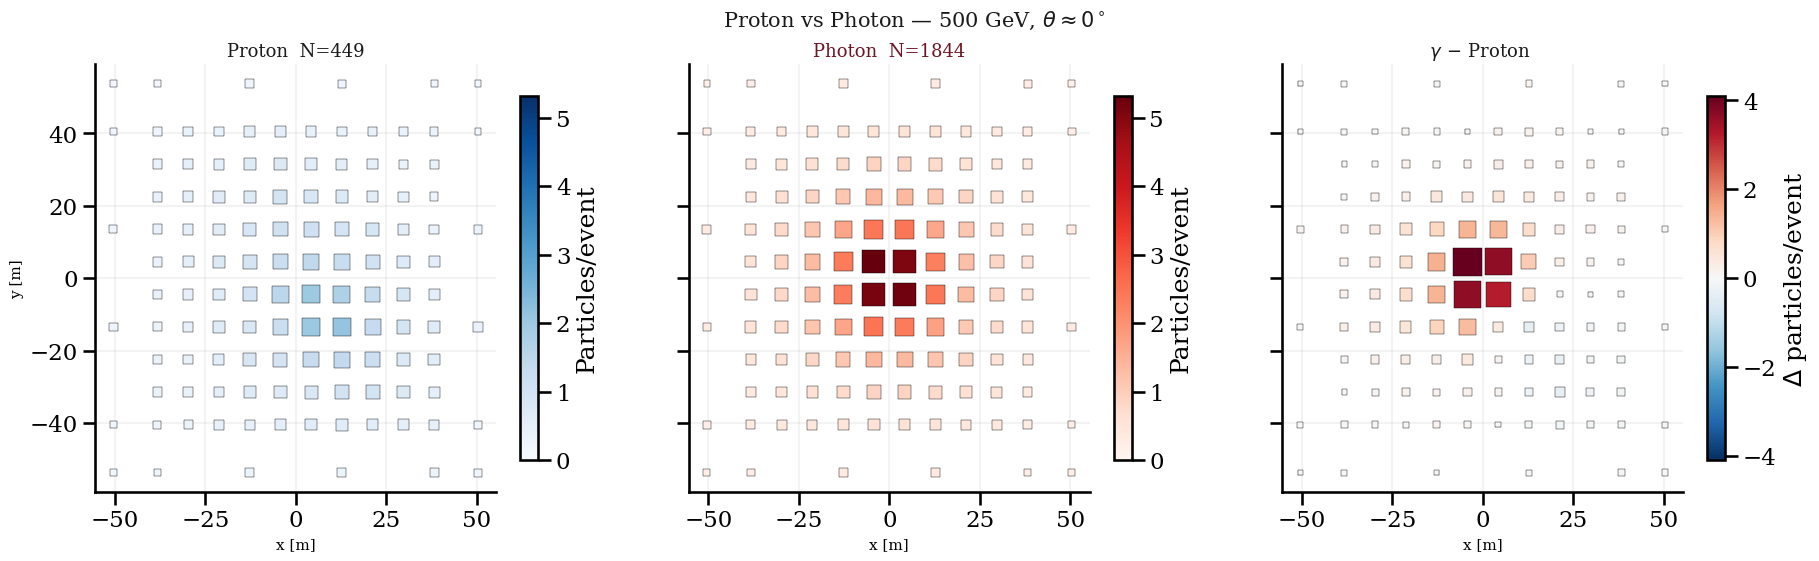

In [12]:
# ============================================================ #
# Sección 3 — Comparación directa Protón vs Fotón             #
# ============================================================ #
COMP_ENERGY = "5E2"
COMP_ANGLE  = 0.0

print(f"Calculando comparacion ({ENERGY_LABELS[COMP_ENERGY]}, theta~{COMP_ANGLE}deg)...")

_comp = {}
for _p in PARTICLES_LIST:
    _mask = (
        (df_filtered["particle"] == _p)
        & (df_filtered["energy"] == COMP_ENERGY)
        & (df_filtered["angle"].between(COMP_ANGLE - ANGLE_TOL, COMP_ANGLE + ANGLE_TOL))
    )
    _comp[_p] = compute_avg_footprint(df_filtered[_mask])

_proton_df, _n_proton = _comp["Proton"]
_photon_df, _n_photon = _comp["Photon"]

_merged = pd.merge(
    _proton_df[["detector_id", "x_center", "y_center", "avg_particles"]].rename(
        columns={"avg_particles": "proton"}
    ),
    _photon_df[["detector_id", "x_center", "y_center", "avg_particles"]].rename(
        columns={"avg_particles": "photon"}
    ),
    on=["detector_id", "x_center", "y_center"],
    how="outer",
).fillna(0)
_merged["diff"] = _merged["photon"] - _merged["proton"]

_vmax_comp = max(float(_proton_df["avg_particles"].max()),
                 float(_photon_df["avg_particles"].max()))
_norm_comp  = plt.Normalize(0, _vmax_comp)
_vabs_diff  = max(abs(float(_merged["diff"].min())),
                  abs(float(_merged["diff"].max())))
_norm_diff  = plt.Normalize(-_vabs_diff, _vabs_diff)

fig3, axes3 = plt.subplots(
    1, 3, figsize=(18, 5.5),
    sharex=True, sharey=True, constrained_layout=True,
)
fig3.suptitle(
    f"Proton vs Photon — {ENERGY_LABELS[COMP_ENERGY]}, $\\theta \\approx {COMP_ANGLE:.0f}^\\circ$",
    fontsize=15, color=CONDOR_BLACK,
)

_panels = [
    ("Proton",   _proton_df, "avg_particles", "Blues",  _norm_comp, CONDOR_BLACK, f"N={_n_proton}"),
    ("Photon",   _photon_df, "avg_particles", "Reds",   _norm_comp, CONDOR_RED,   f"N={_n_photon}"),
    (r"$\gamma\,-\,$Proton", _merged,   "diff",    "RdBu_r", _norm_diff, CONDOR_BLACK, ""),
]

for _ax, (_title, _df, _col, _cm, _norm, _tc, _extra) in zip(axes3, _panels):
    _ax.scatter(detector_catalog["x_center"], detector_catalog["y_center"],
                c=CONDOR_GRAY, s=18, marker="s", edgecolor="none", alpha=0.4, zorder=1)
    _vals = _df[_col]
    if _col == "diff":
        _s = np.clip(np.abs(_vals) / (_vabs_diff + 1e-9) * 400 + 15, 15, 600)
    else:
        _s = np.clip(np.log1p(_vals) * 150, 15, 700)
    _sc = _ax.scatter(
        _df["x_center"], _df["y_center"],
        s=_s, c=_vals, cmap=_cm, norm=_norm,
        marker="s", edgecolor="k", linewidth=0.3, zorder=2,
    )
    _label = "Particles/event" if _col != "diff" else r"$\Delta$ particles/event"
    fig3.colorbar(_sc, ax=_ax, label=_label, shrink=0.85)
    _ax.set_title(f"{_title}  {_extra}", fontsize=13, color=_tc)
    _ax.set_aspect("equal")
    _ax.grid(alpha=0.15)
    _ax.set_xlabel("x [m]", fontsize=11)

axes3[0].set_ylabel("y [m]", fontsize=11)
plt.savefig(VIZ_DIR / "shower_proton_vs_photon.png", dpi=150, bbox_inches="tight")
plt.show()
